**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Erick Gabriel Santiago Suenaga

# Tarea 3: Notebook de regresión

Esta tarea realiza primero la **regresión** para predecir cuánto vale la calificación `quality` y después **clasificación** para decidir si un vino es bueno (`quality` ≥ 7) o no. En los dos casos se usa el mismo modelo, `LinearRegression` con las once variables fisicoquímicas, y la misma partición 80/20 con `random_state=42`.

Cada parte se compara contra una línea base que no mira el vino: en regresión, predecir siempre el promedio; en clasificación, decir siempre «no bueno». La pregunta de fondo es qué cambia cuando la variable objetivo deja de ser un número y pasa a ser una clase, y qué le falla a la recta en el segundo caso.

---

## Preparación

Se usan NumPy, pandas y Matplotlib para los datos y las gráficas, y scikit-learn para el modelo, la partición y las métricas. Los colores son los de las sesiones anteriores: el naranja se reserva para lo que produce el modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)

numpy        2.1.3
pandas       2.2.3
matplotlib   3.10.0
scikit-learn 1.6.1


In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
NARANJA = "#E76A28"     # lo que produce el modelo
GRIS = "#5B6584"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlecolor": AZUL_OSCURO,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": AZUL_OSCURO,
    "axes.edgecolor": "#C9CFDF",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E6EF",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "legend.frameon": False,
})

SEMILLA = 42    # fija las particiones y los sorteos para que los resultados se repitan

---

### Los datos

Calidad de vinos tintos

Cada fila es una muestra de vino tinto portugués de la región del Vinho Verde, al norte de Portugal. Las once primeras columnas son resultados de pruebas fisicoquímicas de laboratorio y la última, `quality`, es una calificación sensorial.

- **Quién lo recolectó.** Paulo Cortez, António Cerdeira, Fernando Almeida, Telmo Matos y José Reis, en el artículo *Modeling wine preferences by data mining from physicochemical properties* (2009). Se donó al repositorio UCI Machine Learning Repository el 6 de octubre de 2009. La página de UCI no declara la fecha en que se tomaron las muestras.
- **Unidad de observación.** Una muestra de vino tinto. El archivo trae 1,599 muestras; los vinos blancos del mismo estudio están en otro archivo y no se usan aquí.
- **Variable objetivo.** `quality`: la mediana de al menos tres evaluaciones de catadores expertos, en una escala de 0 (muy malo) a 10 (excelente). En este archivo toma valores de 3 a 8.
- **Licencia.** Creative Commons Attribution 4.0 International (CC BY 4.0), según la página del dataset en UCI.
- **Enlace.** https://doi.org/10.24432/C56S3T

El archivo de esta tarea separa las columnas con punto y coma, como lo publica UCI. La celda de carga lo detecta: si al leerlo con `;` queda una sola columna, lo vuelve a leer con comas, que es como lo guarda la copia del repositorio del curso.

In [3]:
vinos = pd.read_csv("winequality-red.csv", sep=";")
if vinos.shape[1] == 1:                       # copia separada por comas
    vinos = pd.read_csv("winequality-red.csv")

print(f"{vinos.shape[0]} vinos × {vinos.shape[1]} columnas")
vinos.head()

1599 vinos × 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
resumen = vinos.agg(["min", "max"]).T
resumen["faltantes"] = vinos.isna().sum()
print("Filas duplicadas (todas las columnas iguales):", vinos.duplicated().sum())
resumen.round(3)

Filas duplicadas (todas las columnas iguales): 240


,min,max,faltantes
fixed acidity,4.600,15.900,0
volatile acidity,0.120,1.580,0
citric acid,0.000,1.000,0
residual sugar,0.900,15.500,0
chlorides,0.012,0.611,0
free sulfur dioxide,1.000,72.000,0
total sulfur dioxide,6.000,289.000,0
density,0.990,1.004,0
pH,2.740,4.010,0
sulphates,0.330,2.000,0


Las once variables son numéricas continuas y `quality` es un entero. No hay valores faltantes. Sí hay **240 filas duplicadas** (15 % del archivo): muestras con exactamente las mismas once mediciones y la misma calidad. No se eliminan, porque la tarea parte el archivo tal como viene, pero conviene tenerlo presente: un vino repetido puede caer en entrenamiento y en prueba a la vez, y eso hace la evaluación algo más optimista de lo que sería con vinos totalmente nuevos. Más adelante se cuenta cuántos casos son.


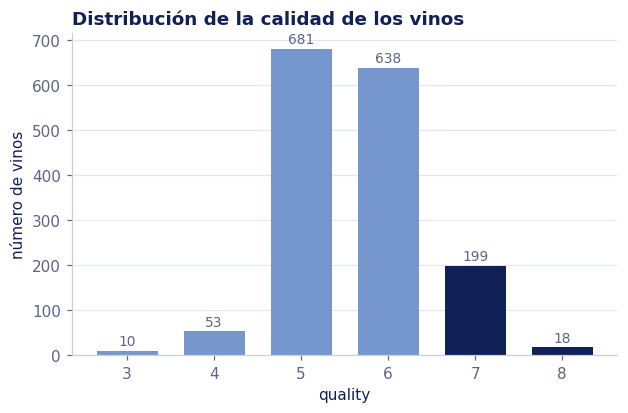

Calidad 5 o 6: 1319 de 1599 vinos (82.5%)
Calidad 7 o más: 217 vinos (13.6%)


In [5]:
conteo = vinos["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.4, 3.8))
colores = [AZUL if q < 7 else AZUL_OSCURO for q in conteo.index]
ax.bar(conteo.index, conteo.values, color=colores, width=0.7)
for q, n in conteo.items():
    ax.text(q, n + 12, f"{n}", ha="center", color=GRIS, fontsize=9)
ax.set_xlabel("quality")
ax.set_ylabel("número de vinos")
ax.set_title("Distribución de la calidad de los vinos")
ax.grid(axis="x", visible=False)
plt.show()

print(f"Calidad 5 o 6: {conteo[[5, 6]].sum()} de {conteo.sum()} vinos ({conteo[[5, 6]].sum() / conteo.sum():.1%})")
print(f"Calidad 7 o más: {conteo[conteo.index >= 7].sum()} vinos ({conteo[conteo.index >= 7].sum() / conteo.sum():.1%})")

Los vinos se concentran en el centro de la escala: 1,319 de 1,599 (82.5 %) tienen calidad 5 o 6. Los extremos son raros: 10 vinos con calidad 3, 18 con calidad 8. Los vinos de calidad 7 o más (barras oscuras) son 217, el 13.6 %. Esto importa para las dos partes de la tarea: la regresión tiene poca variación que explicar, y la clase «bueno» de la parte de clasificación es minoritaria.

---

### Partición 80/20

Se separa el 20 % de los vinos como prueba y el modelo se ajusta solo con el 80 % restante, con `random_state=42`. Las columnas de entrada son las once variables fisicoquímicas, y `quality` es la variable que se predice.

In [6]:
from sklearn.model_selection import train_test_split

X = vinos.drop(columns="quality")
y = vinos["quality"]

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)

print(f"Entrenamiento: {len(X_entrena)} vinos")
print(f"Prueba:         {len(X_prueba)} vinos")

claves_entrena = set(X_entrena.apply(tuple, axis=1))
gemelos = sum(fila in claves_entrena for fila in X_prueba.apply(tuple, axis=1))
print(f"Vinos de prueba con las once mediciones idénticas a un vino de entrenamiento: {gemelos}")

Entrenamiento: 1279 vinos
Prueba:         320 vinos
Vinos de prueba con las once mediciones idénticas a un vino de entrenamiento: 64


Quedan 1,279 vinos para entrenar y 320 para probar. De los 320 de prueba, 64 (20 %) tienen un gemelo exacto en entrenamiento, consecuencia de las filas duplicadas. Esos vinos no son realmente «nuevos» para el modelo, así que las métricas de prueba que siguen son un poco más favorables que las de un conjunto sin repetidos.

---

## Regresión lineal simple

Antes de la regresión múltiple se ajusta una recta con **una sola variable**, `alcohol`, la más ligada a la calidad. Sirve para ver la idea en dos dimensiones, interpretar la pendiente y tener un punto intermedio entre la línea base y el modelo con las once variables.

Se utilizará la variable que más se relaciona con `quality`. Se mide con la matriz de correlación de Pearson de todas las columnas; la fila (o columna) de `quality` dice cuánto se asocia cada variable con la calidad.

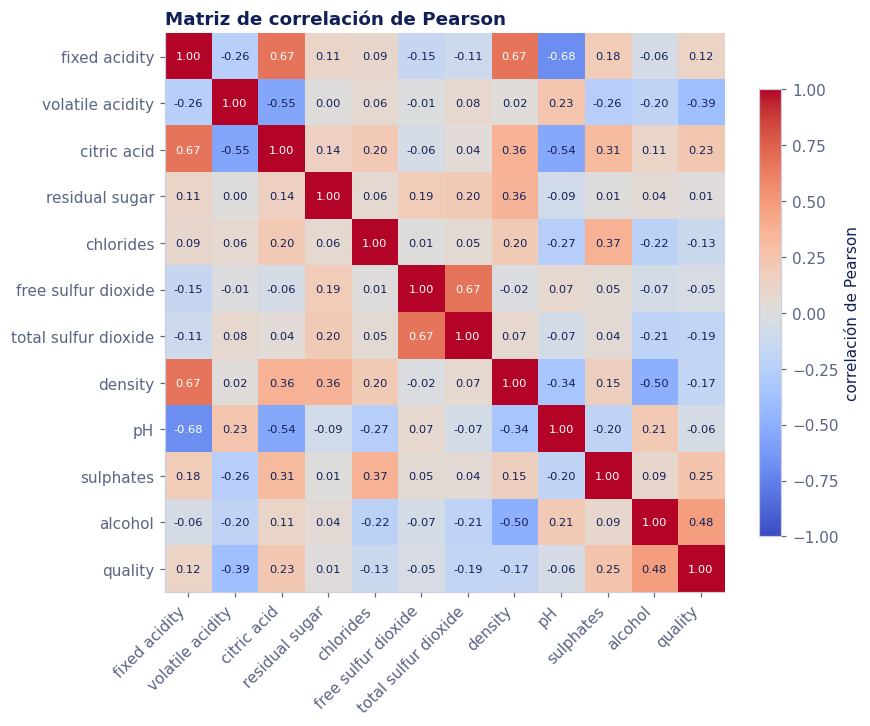

In [7]:
matriz_pearson = vinos.corr(method="pearson")

fig, ax = plt.subplots(figsize=(8.2, 6.6))
im = ax.imshow(matriz_pearson, cmap="coolwarm", vmin=-1, vmax=1)
nombres = matriz_pearson.columns
ax.set_xticks(range(len(nombres)), nombres, rotation=45, ha="right")
ax.set_yticks(range(len(nombres)), nombres)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        v = matriz_pearson.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.6 else AZUL_OSCURO)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlación de Pearson")
ax.set_title("Matriz de correlación de Pearson")
plt.show()

En la fila de `quality`, `alcohol` es la variable con la correlación positiva más fuerte (r = 0.48), seguida de `sulphates` (0.25) y `citric acid` (0.23); `volatile acidity` tiene la negativa más fuerte (r = −0.39). `residual sugar` casi no se relaciona de forma lineal con la calidad (r = 0.01). Por eso la recta simple se ajusta con `alcohol`.

La matriz también muestra relaciones entre las propias variables de entrada, como `fixed acidity` con `pH` (−0.68) o con `density` (0.67). Eso no afecta la recta simple, que usa una sola variable, pero conviene tenerlo presente para la regresión múltiple.

Los coeficientes se calculan primero **a mano**, con las fórmulas de mínimos cuadrados de la sesión 10, y se comprueban con scikit-learn. Aquí la recta solo describe la tendencia, así que se ajusta con los 1,599 vinos; la evaluación con la partición 80/20 viene más adelante.

In [8]:
from sklearn.linear_model import LinearRegression

x = vinos["alcohol"].to_numpy()          # variable independiente
y_obs = vinos["quality"].to_numpy()      # variable dependiente

# Mínimos cuadrados
theta1 = np.sum((x - x.mean()) * (y_obs - y_obs.mean())) / np.sum((x - x.mean()) ** 2)
theta0 = y_obs.mean() - theta1 * x.mean()

# La misma recta con scikit-learn
chequeo = LinearRegression().fit(vinos[["alcohol"]], vinos["quality"])

print(f"A mano:        θ0 = {theta0:.2f}   θ1 = {theta1:.3f}")
print(f"scikit-learn:  θ0 = {chequeo.intercept_:.2f}   θ1 = {chequeo.coef_[0]:.3f}")
print("Coinciden:", np.allclose([theta0, theta1], [chequeo.intercept_, chequeo.coef_[0]]))
print(f"alcohol en los datos: de {x.min():.1f} % a {x.max():.1f} %")

A mano:        θ0 = 1.87   θ1 = 0.361
scikit-learn:  θ0 = 1.87   θ1 = 0.361
Coinciden: True
alcohol en los datos: de 8.4 % a 14.9 %


La recta es ŷ = 1.87 + 0.361 · `alcohol`. La **pendiente** (θ₁ = 0.361) dice que, en promedio, cada punto porcentual adicional de alcohol va acompañado de 0.36 puntos más de calidad; el signo positivo indica una relación directa. Es una asociación entre las dos columnas, no prueba que subir el alcohol cause una mejor calificación. El **intercepto** (θ₀ = 1.87) sería la predicción para un vino con 0 % de alcohol, algo que no existe en los datos (van de 8.4 % a 14.9 %), así que solo ubica la recta y no se interpreta por sí mismo. El cálculo a mano y el de scikit-learn dan lo mismo.

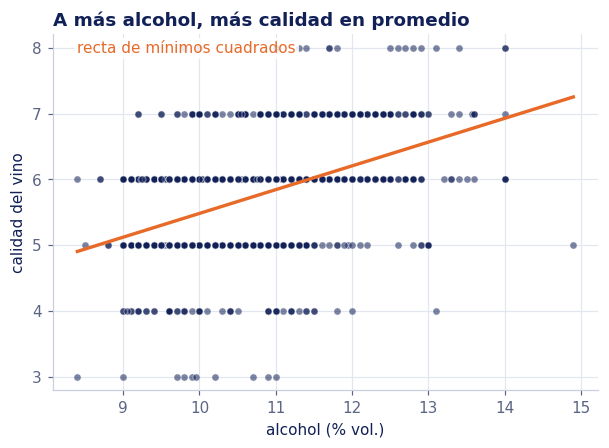

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.scatter(x, y_obs, s=22, color=AZUL_OSCURO, alpha=0.55, edgecolor="white", linewidth=0.5)
malla = np.linspace(x.min(), x.max(), 100)
ax.plot(malla, theta0 + theta1 * malla, color=NARANJA, linewidth=2.2)
ax.text(x.min(), 8.1, "recta de mínimos cuadrados", color=NARANJA, ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85))

ax.set_ylim(2.8, 8.2)
ax.set_xlabel("alcohol (% vol.)")
ax.set_ylabel("calidad del vino")
ax.set_title("A más alcohol, más calidad en promedio")
plt.show()

Como `quality` solo toma valores enteros, los puntos forman filas horizontales, y donde se encima más de un vino el color se vuelve más oscuro. La recta atraviesa la nube y sube de forma suave, pero la dispersión alrededor de ella es grande: con el mismo porcentaje de alcohol hay vinos de calidades muy distintas. El alcohol por sí solo ayuda a predecir, aunque no alcanza.

## Regresión lineal múltiple

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {"RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_real, y_pred),
            "R²": r2_score(y_real, y_pred)}


modelo = LinearRegression().fit(X_entrena, y_entrena)

pred_base = np.full(len(y_prueba), y_entrena.mean())
pred_modelo = modelo.predict(X_prueba)

tabla_prueba = pd.DataFrame({
    "promedio (línea base)": metricas(y_prueba, pred_base),
    "regresión lineal": metricas(y_prueba, pred_modelo),
}).T

print(f"Promedio de quality en entrenamiento: {y_entrena.mean():.3f}")
tabla_prueba.round(3)

Promedio de quality en entrenamiento: 5.624


,RMSE,MAE,R²
promedio (línea base),0.811,0.685,-0.006
regresión lineal,0.625,0.504,0.403


En prueba, la regresión lineal tiene un **RMSE de 0.625** y un **R² de 0.403**; la línea base, un RMSE de 0.811 y un R² de −0.006. El RMSE está en las unidades de `quality`, así que se lee directo: el modelo se equivoca típicamente por unos 0.6 puntos de calificación, contra 0.8 de predecir siempre el promedio. Es una reducción de 23 % en el RMSE. El R² dice lo mismo como proporción: el modelo elimina el 40 % del error cuadrático que se comete al predecir con el promedio.

El R² de la línea base sale ligeramente negativo por la misma razón que en la sesión 10: su promedio (5.624) se calculó en entrenamiento y se evalúa en prueba, donde el promedio real es otro (5.684).

## Las tres predicciones juntas

Se ajusta la recta con `alcohol` solo con los vinos de entrenamiento, como el resto de los modelos de esta sección, y se evalúa en los mismos 320 vinos de prueba junto con la línea base y la regresión múltiple.

In [11]:
modelo_simple = LinearRegression().fit(X_entrena[["alcohol"]], y_entrena)
pred_simple = modelo_simple.predict(X_prueba[["alcohol"]])

print(f"Recta ajustada solo con entrenamiento: ŷ = {modelo_simple.intercept_:.2f} + {modelo_simple.coef_[0]:.3f} · alcohol")

tres = pd.DataFrame({
    "promedio (línea base)": metricas(y_prueba, pred_base),
    "regresión simple (alcohol)": metricas(y_prueba, pred_simple),
    "regresión múltiple (11 variables)": metricas(y_prueba, pred_modelo),
}).T
tres.round(3)

Recta ajustada solo con entrenamiento: ŷ = 1.85 + 0.362 · alcohol


,RMSE,MAE,R²
promedio (línea base),0.811,0.685,-0.006
regresión simple (alcohol),0.707,0.575,0.236
regresión múltiple (11 variables),0.625,0.504,0.403


Con una sola variable el RMSE baja de 0.811 (promedio) a 0.707 y el R² sube de −0.006 a 0.236: usar solo el alcohol ya reduce 13 % el error de la línea base. Las once variables llegan a un RMSE de 0.625 y un R² de 0.403, es decir, las otras diez variables aportan una mejora adicional (el RMSE baja otros 0.08 puntos y el R² pasa de 0.24 a 0.40).

In [12]:
ss_res = np.sum((y_prueba - pred_modelo) ** 2)           # error del modelo
ss_tot = np.sum((y_prueba - y_prueba.mean()) ** 2)       # error de predecir con el promedio de prueba

print(f"R² a mano:       {1 - ss_res / ss_tot:.4f}")
print(f"R² scikit-learn: {r2_score(y_prueba, pred_modelo):.4f}")
print(f"RMSE: el modelo reduce {1 - tabla_prueba.loc['regresión lineal', 'RMSE'] / tabla_prueba.loc['promedio (línea base)', 'RMSE']:.0%} el error de la línea base")

R² a mano:       0.4032
R² scikit-learn: 0.4032
RMSE: el modelo reduce 23% el error de la línea base


In [13]:
pd.DataFrame({
    "entrenamiento": metricas(y_entrena, modelo.predict(X_entrena)),
    "prueba": metricas(y_prueba, pred_modelo),
}).T.round(3)

,RMSE,MAE,R²
entrenamiento,0.651,0.500,0.348
prueba,0.625,0.504,0.403


No hay señales de sobreajuste: el RMSE de entrenamiento (0.651) es incluso un poco mayor que el de prueba (0.625), y el R² de entrenamiento (0.348) es menor que el de prueba (0.403). Un modelo lineal con once variables y 1,279 vinos tiene poco margen para memorizar. Que la prueba salga mejor que el entrenamiento no es una ventaja real del modelo: con solo 320 vinos de prueba, y 64 de ellos repetidos de entrenamiento, el resultado depende de la partición.

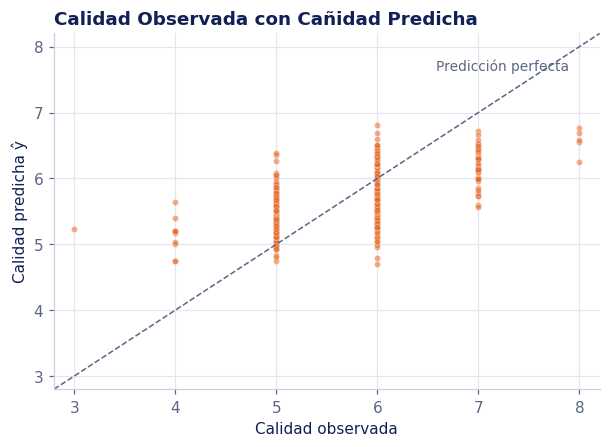

Rango de las predicciones: 4.71 a 6.80
ŷ promedio en vinos de calidad 7 o más: 6.22
ŷ promedio en vinos de calidad menor a 7: 5.55


In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.plot([2.8, 8.2], [2.8, 8.2], color=GRIS, linewidth=1, linestyle="--")
ax.scatter(y_prueba, pred_modelo,
           s=16, color=NARANJA, alpha=0.55, edgecolor="white", linewidth=0.3)
ax.text(7.9, 7.6, "Predicción perfecta", color=GRIS, ha="right", va="bottom", fontsize=9, rotation=0)
ax.set_xlim(2.8, 8.2)
ax.set_ylim(2.8, 8.2)
ax.set_xlabel("Calidad observada")
ax.set_ylabel("Calidad predicha ŷ")
ax.set_title("Calidad Observada con Cañidad Predicha")
plt.show()

print(f"Rango de las predicciones: {pred_modelo.min():.2f} a {pred_modelo.max():.2f}")
print(f"ŷ promedio en vinos de calidad 7 o más: {pred_modelo[y_prueba >= 7].mean():.2f}")
print(f"ŷ promedio en vinos de calidad menor a 7: {pred_modelo[y_prueba < 7].mean():.2f}")

Si el modelo fuera perfecto, los puntos caerían sobre la diagonal. La nube sí sube con la calidad observada, pero es mucho más plana que la diagonal: las predicciones solo van de 4.71 a 6.80, y el modelo nunca predice calidades cercanas a 3 ni a 8. Es lo esperable cuando casi todos los vinos están en 5 y 6 y las variables explican solo una parte de la calificación: la recta se queda cerca del promedio. Aun así ordena razonablemente a los vinos: los de calidad 7 o más tienen una predicción promedio de 6.22, contra 5.55 de los demás. Esa capacidad de ordenar es lo que se pone a prueba en la parte siguiente.

---

## Clasificación

Se define **bueno = `quality` ≥ 7**; el corte es el que pide la tarea, no uno enológico. La columna se codifica como 1 (bueno) y 0 (no bueno), y con ella se ajusta **la misma regresión lineal**, con las mismas once variables y la misma partición. La recta predice un número ŷ, y se clasifica como bueno si ŷ ≥ 0.5.

In [15]:
bueno_entrena = (y_entrena >= 7).astype(int)
bueno_prueba = (y_prueba >= 7).astype(int)

# La partición es la misma: se obtiene igual si se parte directamente la columna bueno
_, _, b_e, b_p = train_test_split(X, (y >= 7).astype(int), test_size=0.2, random_state=SEMILLA)
assert (b_e.index == bueno_entrena.index).all() and (b_p.index == bueno_prueba.index).all()

print(f"Buenos en entrenamiento: {bueno_entrena.sum()} de {len(bueno_entrena)} ({bueno_entrena.mean():.1%})")
print(f"Buenos en prueba:        {bueno_prueba.sum()} de {len(bueno_prueba)} ({bueno_prueba.mean():.1%})")

Buenos en entrenamiento: 170 de 1279 (13.3%)
Buenos en prueba:        47 de 320 (14.7%)


In [16]:
recta = LinearRegression().fit(X_entrena, bueno_entrena)
y_gorro = recta.predict(X_prueba)              # números, no clases
clase = (y_gorro >= 0.5).astype(int)           # umbral: ŷ ≥ 0.5 → bueno

In [17]:
from sklearn.metrics import accuracy_score

siempre_no = np.zeros(len(bueno_prueba), dtype=int)          # línea base: siempre «no bueno»
fuera = int(((y_gorro < 0) | (y_gorro > 1)).sum())
debajo = int((y_gorro < 0).sum())
arriba = int((y_gorro > 1).sum())
detectados = int(((clase == 1) & (bueno_prueba == 1)).sum())
aciertos = int((clase == bueno_prueba).sum())
aciertos_base = int((siempre_no == bueno_prueba).sum())

print(f"Aciertos de la recta:            {accuracy_score(bueno_prueba, clase):.2%}  ({aciertos} de {len(clase)})")
print(f"Aciertos diciendo siempre «no»:  {accuracy_score(bueno_prueba, siempre_no):.2%}  ({aciertos_base} de {len(clase)})")
print(f"ŷ fuera de [0, 1]:               {fuera} de {len(y_gorro)}  ({debajo} menores que 0 y {arriba} mayores que 1)")
print()
print(f"Rango de ŷ: {y_gorro.min():.2f} a {y_gorro.max():.2f}")
print(f"Vinos clasificados como buenos:  {clase.sum()}  (de los cuales {detectados} sí lo son)")
print(f"Vinos buenos detectados:         {detectados} de {bueno_prueba.sum()}")

Aciertos de la recta:            86.25%  (276 de 320)
Aciertos diciendo siempre «no»:  85.31%  (273 de 320)
ŷ fuera de [0, 1]:               82 de 320  (82 menores que 0 y 0 mayores que 1)

Rango de ŷ: -0.15 a 0.54
Vinos clasificados como buenos:  7  (de los cuales 5 sí lo son)
Vinos buenos detectados:         5 de 47


La recta acierta el **86.25 %** de los vinos de prueba (276 de 320). Suena bien hasta compararlo con la línea base: decir siempre «no bueno» acierta el **85.31 %** (273 de 320), porque la mayoría de los vinos no es buena. La diferencia es de tres vinos, menos de un punto porcentual. Además, la recta casi no encuentra lo que importa: solo clasifica como buenos 7 vinos, y apenas 5 de los 47 buenos de prueba son detectados.

Sobre el rango de ŷ: **82 de las 320 predicciones (25.6 %) son menores que 0** y ninguna es mayor que 1. Un valor negativo no se puede leer como probabilidad ni como ninguna otra cosa que tenga sentido para una clase. La gráfica siguiente muestra de dónde sale esto.

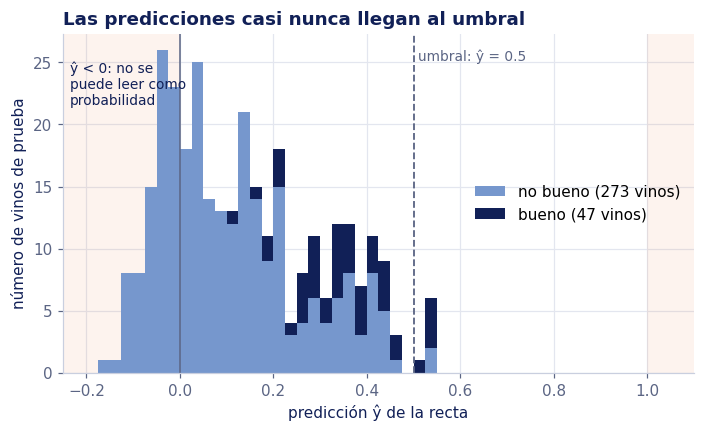

ŷ promedio en vinos buenos:    0.34
ŷ promedio en vinos no buenos: 0.10
Vinos con ŷ ≥ 0.5: 7
Vinos con ŷ < 0.3: 253 de 320 (79%)


In [18]:
fig, ax = plt.subplots(figsize=(7.4, 4))

ax.axvspan(-0.25, 0, color=NARANJA, alpha=0.08, linewidth=0)
ax.axvspan(1, 1.1, color=NARANJA, alpha=0.08, linewidth=0)
cortes = np.linspace(-0.2, 0.6, 33)
ax.hist([y_gorro[bueno_prueba == 0], y_gorro[bueno_prueba == 1]], bins=cortes, stacked=True,
        color=[AZUL, AZUL_OSCURO], label=["no bueno (273 vinos)", "bueno (47 vinos)"])
ax.axvline(0.5, color=GRIS, linewidth=1.2, linestyle="--")
ax.axvline(0, color=GRIS, linewidth=1)

ax.text(0.51, ax.get_ylim()[1] * 0.92, "umbral: ŷ = 0.5", color=GRIS, fontsize=9)
ax.text(-0.235, ax.get_ylim()[1] * 0.92, "ŷ < 0: no se\npuede leer como\nprobabilidad", color=AZUL_OSCURO, fontsize=9, va="top")
ax.set_xlim(-0.25, 1.1)
ax.set_xlabel("predicción ŷ de la recta")
ax.set_ylabel("número de vinos de prueba")
ax.set_title("Las predicciones casi nunca llegan al umbral")
ax.legend(loc="center right")
plt.show()

print(f"ŷ promedio en vinos buenos:    {y_gorro[bueno_prueba == 1].mean():.2f}")
print(f"ŷ promedio en vinos no buenos: {y_gorro[bueno_prueba == 0].mean():.2f}")
print(f"Vinos con ŷ ≥ 0.5: {(y_gorro >= 0.5).sum()}")
print(f"Vinos con ŷ < 0.3: {(y_gorro < 0.3).sum()} de {len(y_gorro)} ({(y_gorro < 0.3).mean():.0%})")

La recta ordena en la dirección correcta: los vinos buenos tienen una ŷ promedio de 0.34 y los demás, de 0.10. Pero los dos grupos se traslapan mucho, y el 79 % de las predicciones (253 de 320) es menor que 0.3, lejos del umbral. Solo 7 vinos lo cruzan, y la ŷ más alta es 0.54. La razón es que solo 13.3 % de los vinos de entrenamiento son buenos: una recta ajustada a casi puros ceros tiende a quedarse baja, y el umbral de 0.5 queda en una zona que casi no visita. A la izquierda, la zona sombreada marca las predicciones negativas (82): la recta no tiene nada que la detenga en 0, y todas ellas corresponden a vinos que no son buenos. Eso es lo que pasa cuando se le pide a una recta que describa una probabilidad.

---

## Conclusión

En la regresión se pregunta cuánto vale `quality`, y la recta sí aporta, en prueba tiene un RMSE de 0.62 contra 0.81 de predecir siempre el promedio y un R² de 0.40 contra −0.01 (la recta con solo `alcohol` queda en medio, con 0.71 y 0.24). En la clasificación la respuesta es una clase, solo el 13.6 % de los vinos son buenos, y el mismo modelo queda casi empatado con no hacer nada: acierta el 86.25 % de los vinos de prueba contra el 85.31 % de decir siempre «no bueno» (tres vinos más de 320) y detecta solo 5 de los 47 vinos buenos, así que el porcentaje de aciertos esconde que casi no distingue la clase que interesa.

---

## Declaración de uso de IA generativa

Este notebook utilizó Claude (Anthropic) como asistente para estructurar el notebook (Markdown) y revisar la redacción de los textos así como la depuración de código.

## Referencias

- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Wine Quality* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T. Licencia CC BY 4.0.
- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2a ed., capítulo 3. Springer. https://www.statlearning.com/
- [scikit-learn: LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) · [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) · [Métricas](https://scikit-learn.org/stable/modules/model_evaluation.html)